<a href="https://colab.research.google.com/github/gaborh0808/1st-PyCrawlerMarathon/blob/master/Panel_Data_ATR_LightGBM_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

正在自動安裝缺失套件: optuna ...
正在下載台股 (^TWII) 與美股 (^GSPC) 數據...
正在批次下載個股數據...
正在建構 Panel Data...
正在計算全市場每日橫截面百分比排名 (Cross-Sectional Rank)...

全市場 Panel 訓練集筆數: 203207 | 測試集筆數: 15627

正在執行 Optuna 超參數調優 (15 次 Iterations，目標：極致化 ROC AUC Score)...

=== Optuna 最佳超參數結果 ===
 - n_estimators: 700
 - learning_rate: 0.01952899398205799
 - max_depth: 4
 - num_leaves: 20
 - min_child_samples: 119
 - subsample: 0.8488316556925596
 - colsample_bytree: 0.662159965586905
 - reg_alpha: 1.0084410638201584
 - reg_lambda: 0.2958827066049724
時序驗證集 Validation ROC AUC Score: 0.5495

正在訓練最終高效能 LightGBM 分類模型...

=== LightGBM 特徵重要性排行榜 (前 20 大，按 Gain 排序) ===


,Feature,Gain_Importance,Split_Count,Gain_Ratio (%)
0,Dist_MA60,19266.125656,588,8.027376
1,ATR_Squeeze,18994.837215,483,7.914342
2,CS_Rank_ATR_Squeeze,16783.708054,454,6.993058
3,Norm_ATR,13758.205573,568,5.732460
4,CS_Rank_Dist_MA60,10322.260147,450,4.300847
5,CS_Rank_Norm_ATR,9990.653607,436,4.162681
6,Alpha_20,8518.435068,355,3.549270
7,LogRet_10,8102.039654,148,3.375776
8,BB_PctB,8002.932973,158,3.334482
9,LogRet_1,7544.967579,232,3.143668


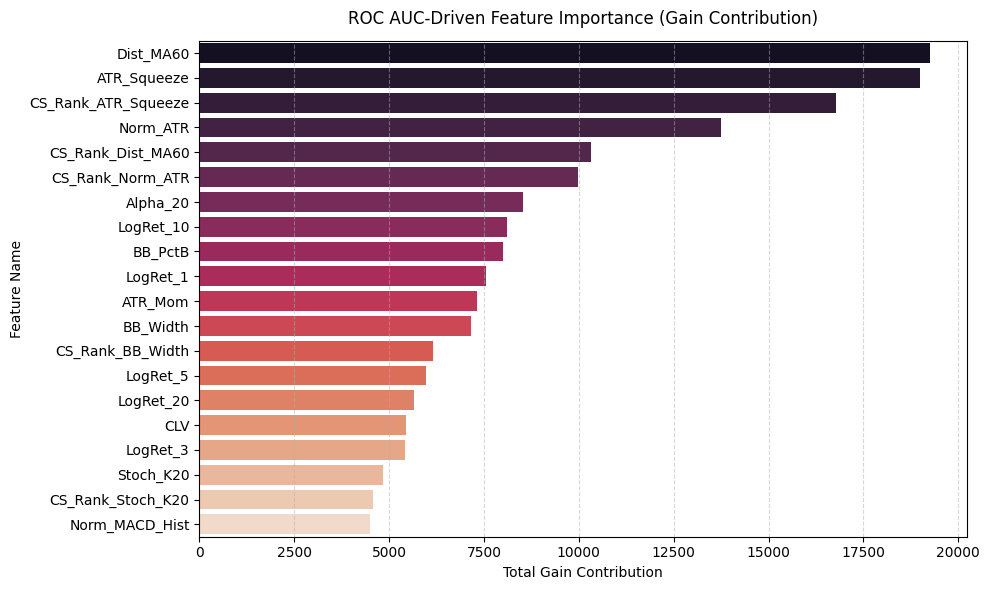


=== Panel Data 模型回測結果 (高勝率組：預測機率 >= 57%) ===
高勝率組訊號數: 97 | 成功數: 69 | 門檻內勝率 (Precision): 71.13%


Price,Ticker,Name,Target,Prob
Date,,,,
2026-04-20,4971.TWO,IET-KY,1.0,0.767789
2026-04-20,4908.TWO,前鼎,1.0,0.728681
2026-06-01,3556.TWO,禾瑞亞,1.0,0.723959
2026-04-30,3016.TW,嘉晶,1.0,0.714829
2026-04-17,4908.TWO,前鼎,1.0,0.714558
2026-05-07,6173.TWO,信昌電,1.0,0.712586
2026-05-04,3016.TW,嘉晶,1.0,0.708320
2026-05-25,3236.TWO,千如,0.0,0.707641
2026-05-25,6173.TWO,信昌電,1.0,0.706821



=== Panel Data 模型回測結果 (低勝率組：預測機率 < 57%) ===
低勝率組訊號數: 15530 | 成功數: 7524 | 門檻外勝率: 48.45%


Price,Ticker,Name,Target,Prob
Date,,,,
2026-05-11,1560.TW,中砂,1.0,0.579801
2026-05-25,3090.TW,日電貿,0.0,0.578376
2026-05-21,6274.TWO,台燿,1.0,0.578291
2026-05-25,2409.TW,友達,0.0,0.577988
2026-05-22,2492.TW,華新科,1.0,0.577907
2026-05-11,3016.TW,嘉晶,0.0,0.577670
2026-04-20,3556.TWO,禾瑞亞,1.0,0.576358
2026-05-21,6426.TW,統新,0.0,0.575983
2026-05-04,3443.TW,創意,1.0,0.575727



=== 全市場測試集整體統計與模型分類效能 ===


,測試集總樣本數,歷史自然勝率 (基線),模型整體準確率 (Accuracy),高勝率組精確率 (Precision),低勝率組實際勝率,模型召回率 (Recall),ROC AUC Score
0,15627,48.59%,51.67%,71.13%,48.45%,0.91%,0.5302



=== 產生 2026-08-19 最新盤後預測建議 (Panel 模型) ===


,股票名稱,股票代號,資料日期,預測勝率
207,世紀,5314,2026-08-19,68.15%
49,乙盛-KY,5243,2026-08-19,63.9%
245,川寶,1595,2026-08-19,62.5%
134,國巨,2327,2026-08-19,62.22%
30,臺慶科,3357,2026-08-19,60.37%
32,聯寶,6821,2026-08-19,59.98%
97,博智,8155,2026-08-19,59.04%
136,凱美,2375,2026-08-19,58.88%
231,嘉晶,3016,2026-08-19,58.78%


In [1]:
# Panel Data、ATR 動態停利停損以及 LightGBM 樹狀機器學習演算法 (AUC 專屬特徵重構與 Optuna 自動調優極致版)
import datetime
import subprocess
import sys
import warnings

# ==========================================
# 0. 自動檢查與安裝必要套件 (融合第二份程式)
# ==========================================
required_packages = {
    'optuna': 'optuna',
    'lightgbm': 'lightgbm',
    'yfinance': 'yfinance',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
    'pandas': 'pandas',
    'numpy': 'numpy',
}


def install_and_import(package_name, install_name):
  try:
    __import__(package_name)
  except ImportError:
    print(f'正在自動安裝缺失套件: {install_name} ...')
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', install_name, '--quiet']
    )


for pkg_import, pkg_install in required_packages.items():
  install_and_import(pkg_import, pkg_install)

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import yfinance as yf
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

try:
  from IPython.display import display
except ImportError:

  def display(x):
    print(x)


# ==========================================
# 1. 股票池定義 (維持既有股票池與對應名稱)
# ==========================================
stock_dict = {
    '0050.TW': '元大台灣50',
    '0056.TW': '元大高股息',
    '00878.TW': '國泰永續高股息',
    '00770.TW': '國泰北美科技',
    '00981A.TW': '統一台股增長主動式',
    'AAPL': 'Apple 蘋果',
    'GOOG': 'Google / Alphabet',
    'META': 'Meta',
    'MSFT': 'Microsoft 微軟',
    'NVDA': 'NVIDIA 輝達',
    'TSM': '台積電 ADR',
    'TSLA': 'Tesla 特斯拉',
    'ENTG': 'Entegris 英特格',
    'SMR': 'NuScale Power 小型核反應爐',
    'BE': 'Bloom Energy 燃料電池',
    'JNJ': 'Johnson & Johnson 嬌生',
    'SPCX': 'SPACs ETF',
    '2382.TW': '廣達',
    '3231.TW': '緯創',
    '6669.TW': '緯穎',
    '2317.TW': '鴻海',
    '2356.TW': '英業達',
    '2324.TW': '仁寶',
    '2376.TW': '技嘉',
    '3706.TW': '神達',
    '2377.TW': '微星',
    '2357.TW': '華碩',
    '4938.TW': '和碩',
    '3005.TW': '神基',
    '5274.TWO': '信驊',
    '3689.TWO': '湧德',
    '3357.TWO': '臺慶科',
    '6862.TW': '三集瑞-KY',
    '6821.TWO': '聯寶',
    '3207.TWO': '耀勝',
    '6197.TW': '佳必琪',
    '8103.TW': '瀚荃',
    '3526.TWO': '凡甲',
    '3605.TW': '宏致',
    '2345.TW': '智邦',
    '5388.TW': '中磊',
    '3558.TWO': '神準',
    '3704.TW': '合勤控',
    '4906.TW': '正文',
    '8210.TW': '勤誠',
    '6117.TW': '迎廣',
    '6235.TW': '華孚',
    '2354.TW': '鴻準',
    '3376.TW': '新日興',
    '3548.TWO': '兆利',
    '5243.TW': '乙盛-KY',
    '4966.TWO': '譜瑞-KY',
    '5269.TW': '祥碩',
    '6104.TWO': '創唯',
    '6756.TW': '威鋒電子',
    '6715.TW': '嘉基',
    '3533.TW': '嘉澤',
    '3217.TWO': '優群',
    '3023.TW': '信邦',
    '2392.TW': '正崴',
    '3035.TW': '智原',
    '6643.TWO': 'M31',
    '2308.TW': '台達電',
    '2301.TW': '光寶科',
    '6282.TW': '康舒',
    '6412.TW': '群電',
    '3665.TW': '貿聯-KY',
    '3017.TW': '奇鋐',
    '3324.TWO': '雙鴻',
    '3653.TW': '健策',
    '2421.TW': '建準',
    '8996.TW': '高力',
    '3483.TWO': '力致',
    '6230.TW': '尼得科超眾',
    '3013.TW': '晟銘電',
    '6805.TW': '富世達',
    '6781.TW': 'AES-KY',
    '3211.TWO': '順達',
    '6121.TWO': '新普',
    '3323.TWO': '加百裕',
    '3625.TWO': '西勝',
    '8038.TWO': '長園科',
    '4931.TWO': '新盛力',
    '1519.TW': '華城',
    '1513.TW': '中興電',
    '1514.TW': '亞力',
    '1503.TW': '士電',
    '1609.TW': '大亞',
    '1605.TW': '華新',
    '1608.TW': '華榮',
    '6869.TW': '雲豹能源',
    '3037.TW': '欣興',
    '8046.TW': '南電',
    '3189.TW': '景碩',
    '4958.TW': '臻鼎-KY',
    '2368.TW': '金像電',
    '3044.TW': '健鼎',
    '2313.TW': '華通',
    '8155.TWO': '博智',
    '2383.TW': '台光電',
    '6274.TWO': '台燿',
    '6213.TW': '聯茂',
    '2344.TW': '華邦電',
    '2408.TW': '南亞科',
    '2337.TW': '旺宏',
    '3006.TW': '晶豪科',
    '3260.TWO': '威剛',
    '2451.TW': '創見',
    '4967.TW': '十銓',
    '8271.TW': '宇瞻',
    '5289.TWO': '宜晶',
    '8299.TWO': '群聯',
    '5351.TWO': '鈺創',
    '4979.TWO': '華星光',
    '6442.TW': '光聖',
    '4908.TWO': '前鼎',
    '3163.TWO': '波若威',
    '3450.TW': '聯鈞',
    '6426.TW': '統新',
    '4977.TW': '眾達-KY',
    '6530.TWO': '創威',
    '3363.TWO': '上詮',
    '3234.TWO': '光環',
    '4903.TWO': '聯光通',
    '3081.TWO': '聯亞',
    '4991.TWO': '環宇-KY',
    '4971.TWO': 'IET-KY',
    '6588.TWO': '東典光電',
    '3491.TWO': '昇達科',
    '2314.TW': '台揚',
    '6285.TW': '啟碁',
    '3105.TWO': '穩懋',
    '2455.TW': '全新',
    '3138.TW': '耀登',
    '2419.TW': '仲琦',
    '2327.TW': '國巨',
    '2492.TW': '華新科',
    '2375.TW': '凱美',
    '2478.TW': '大毅',
    '3026.TW': '禾伸堂',
    '3090.TW': '日電貿',
    '6173.TWO': '信昌電',
    '6155.TW': '鈞寶',
    '6175.TWO': '立敦',
    '5328.TWO': '華容',
    '3236.TWO': '千如',
    '2049.TW': '上銀',
    '4576.TW': '大銀微系統',
    '4585.TW': '達明',
    '2359.TW': '所羅門',
    '6188.TWO': '廣明',
    '8374.TW': '羅昇',
    '5443.TWO': '均豪',
    '6640.TWO': '均華',
    '2464.TW': '盟立',
    '6215.TW': '和椿',
    '4562.TW': '穎漢',
    '1590.TW': '亞德客-KY',
    '1504.TW': '東元',
    '3711.TW': '日月光投控',
    '2449.TW': '京元電子',
    '6257.TW': '矽格',
    '3264.TWO': '欣銓',
    '6239.TW': '力成',
    '2329.TW': '華泰',
    '2441.TW': '超豐',
    '3131.TWO': '弘塑',
    '3583.TW': '辛耘',
    '6187.TWO': '萬潤',
    '2467.TW': '志聖',
    '8027.TWO': '钛昇',
    '3481.TW': '群創',
    '2409.TW': '友達',
    '5434.TW': '崇越',
    '3010.TW': '華立',
    '1560.TW': '中砂',
    '3680.TWO': '家登',
    '5234.TW': '達興材料',
    '4749.TWO': '新應材',
    '8028.TW': '昇陽半導體',
    '6515.TW': '穎崴',
    '6683.TWO': '雍智科技',
    '6510.TWO': '精測',
    '6223.TWO': '旺矽',
    '2330.TW': '台積電',
    '2303.TW': '聯電',
    '2454.TW': '聯發科',
    '3034.TW': '聯詠',
    '3661.TW': '世芯-KY',
    '3443.TW': '創意',
    '4961.TW': '天鈺',
    '6415.TW': '矽力-KY',
    '6531.TW': '愛普*',
    '2404.TW': '漢唐',
    '1773.TW': '勝一',
    '3008.TW': '大立光',
    '4915.TW': '先進光',
    '5288.TW': '匯鑽科',
    '3644.TWO': '凌嘉科',
    '7769.TW': '鴻勁',
    '1303.TW': '南亞',
    '2395.TW': '研華',
    '6166.TW': '凌華',
    '8050.TWO': '廣積',
    '3556.TWO': '禾瑞亞',
    '2414.TW': '精技',
    '6414.TW': '樺漢',
    '3022.TW': '威強電',
    '2397.TW': '友通',
    '5314.TWO': '世紀',
    '2393.TW': '億光',
    '2465.TW': '麗臺',
    '5536.TWO': '聖暉*',
    '2201.TW': '裕隆',
    '2204.TW': '中華',
    '2206.TW': '三陽工業',
    '1536.TW': '和大',
    '2231.TW': '聯嘉',
    '3552.TWO': '同致',
    '6279.TWO': '胡連',
    '2353.TW': '宏碁',
    '8163.TW': '達方',
    '8043.TWO': '蜜望實',
    '2892.TW': '第一金',
    '5880.TW': '合庫金',
    '1210.TW': '大成',
    '1215.TW': '卜蜂',
    '1216.TW': '統一',
    '2912.TW': '統一超',
    '5903.TWO': '全家',
    '6770.TW': '力積電',
    '2342.TW': '茂矽',
    '3707.TWO': '漢磊',
    '3016.TW': '嘉晶',
    '6196.TW': '帆宣',
    '6139.TW': '亞翔',
    '6613.TWO': '朋億*',
    '4755.TW': '三福化',
    '4768.TWO': '晶呈科技',
    '3563.TW': '牧德',
    '1717.TW': '長興',
    '1815.TWO': '富喬',
    '1802.TW': '台玻',
    '5340.TWO': '建榮',
    '5475.TWO': '德宏',
    '3167.TW': '大量',
    '6438.TW': '迅得',
    '1595.TWO': '川寶',
    '6147.TWO': '頎邦',
    '8150.TW': '南茂',
    '6552.TW': '易華電',
    '3305.TW': '昇貿',
    '3631.TWO': '晟楠',
    '2059.TW': '川湖',
    '6584.TWO': '南俊國際',
    '8358.TWO': '金居',
    '8021.TW': '尖點',
    '6672.TW': '騰輝電子-KY',
}


# ==========================================
# 2. 既有 ATR 動態停利停損標籤函數 (維持原邏輯)
# ==========================================
def apply_labeling_atr(df, horizon=10):
  closes = df['Close'].values
  highs = df['High'].values
  lows = df['Low'].values
  labels = np.zeros(len(df))

  high_low = highs - lows
  high_cp = np.abs(highs - np.roll(closes, 1))
  low_cp = np.abs(lows - np.roll(closes, 1))
  tr = np.maximum(high_low, np.maximum(high_cp, low_cp))
  atr = pd.Series(tr).rolling(14).mean().values

  for i in range(len(df) - horizon):
    entry_p = closes[i]
    if np.isnan(atr[i]) or entry_p == 0:
      continue

    upper_target = entry_p + (2.0 * atr[i])
    lower_target = entry_p - (1.5 * atr[i])

    hit = 0
    for step in range(1, horizon + 1):
      if lows[i + step] <= lower_target:
        break
      if highs[i + step] >= upper_target:
        hit = 1
        break
    labels[i] = hit

  labels[-horizon:] = np.nan
  df['Target'] = labels
  return df


# ==========================================
# 3. 專為提升 AUC 打造之重構特徵函數 (維持第一份完整 23 項特徵)
# ==========================================
def compute_panel_features(df):
  d = df.copy()

  # (A) 對數報酬率與超額報酬 (Alpha)
  d['LogRet_1'] = np.log(d['Close'] / (d['Close'].shift(1) + 1e-6))
  d['LogRet_3'] = np.log(d['Close'] / (d['Close'].shift(3) + 1e-6))
  d['LogRet_5'] = np.log(d['Close'] / (d['Close'].shift(5) + 1e-6))
  d['LogRet_10'] = np.log(d['Close'] / (d['Close'].shift(10) + 1e-6))
  d['LogRet_20'] = np.log(d['Close'] / (d['Close'].shift(20) + 1e-6))
  d['Mom_Spread'] = d['LogRet_5'] - d['LogRet_20']

  # 大盤相對 Alpha 計算 (剔除總體市場共振噪音)
  if 'Mkt_Close' in d.columns:
    mkt_ret_5 = np.log(d['Mkt_Close'] / (d['Mkt_Close'].shift(5) + 1e-6))
    mkt_ret_20 = np.log(d['Mkt_Close'] / (d['Mkt_Close'].shift(20) + 1e-6))
    d['Alpha_5'] = d['LogRet_5'] - mkt_ret_5
    d['Alpha_20'] = d['LogRet_20'] - mkt_ret_20
  else:
    d['Alpha_5'] = d['LogRet_5']
    d['Alpha_20'] = d['LogRet_20']

  # (B) 均線結構與高低價位階
  ma5 = d['Close'].rolling(5).mean()
  ma20 = d['Close'].rolling(20).mean()
  ma60 = d['Close'].rolling(60).mean()
  d['MA5_20_Ratio'] = (ma5 - ma20) / (ma20 + 1e-6)
  d['Dist_MA20'] = (d['Close'] - ma20) / (ma20 + 1e-6)
  d['Dist_MA60'] = (d['Close'] - ma60) / (ma60 + 1e-6)

  low_20 = d['Low'].rolling(20).min()
  high_20 = d['High'].rolling(20).max()
  d['Stoch_K20'] = (d['Close'] - low_20) / (high_20 - low_20 + 1e-6)

  # (C) 振盪器指標 (RSI & Normalized MACD)
  delta = d['Close'].diff()
  gain = (delta.where(delta > 0, 0)).rolling(14).mean()
  loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
  rs = gain / (loss + 1e-6)
  d['RSI_14'] = 100 - (100 / (1 + rs))

  ema12 = d['Close'].ewm(span=12, adjust=False).mean()
  ema26 = d['Close'].ewm(span=26, adjust=False).mean()
  macd = ema12 - ema26
  signal = macd.ewm(span=9, adjust=False).mean()
  d['Norm_MACD_Hist'] = (macd - signal) / (d['Close'] + 1e-6)

  # (D) ATR 波動度擴張/壓縮率 (ATR Squeeze & ATR Momentum)
  high_low = d['High'] - d['Low']
  high_cp = np.abs(d['High'] - d['Close'].shift(1))
  low_cp = np.abs(d['Low'] - d['Close'].shift(1))
  tr = np.maximum(high_low, np.maximum(high_cp, low_cp))
  atr5 = tr.rolling(5).mean()
  atr14 = tr.rolling(14).mean()
  atr60 = tr.rolling(60).mean()
  d['ATR_Squeeze'] = atr14 / (atr60 + 1e-6)
  d['ATR_Mom'] = atr5 / (atr14 + 1e-6)  # 短期 ATR 爆發度
  d['Norm_ATR'] = atr14 / (d['Close'] + 1e-6)

  # (E) 布林通道指標 (%B 及 寬度)
  bb_std = d['Close'].rolling(20).std()
  bb_upper = ma20 + (2 * bb_std)
  bb_lower = ma20 - (2 * bb_std)
  d['BB_PctB'] = (d['Close'] - bb_lower) / (bb_upper - bb_lower + 1e-6)
  d['BB_Width'] = (bb_upper - bb_lower) / (ma20 + 1e-6)

  # (F) 量能與量價共振指標 (Volume Dynamics & PV Interaction)
  vol_mean5 = d['Volume'].rolling(5).mean()
  vol_mean20 = d['Volume'].rolling(20).mean()
  vol_std20 = d['Volume'].rolling(20).std()
  d['Vol_Ratio5_20'] = vol_mean5 / (vol_mean20 + 1e-6)
  d['Vol_ZScore'] = (d['Volume'] - vol_mean20) / (vol_std20 + 1e-6)
  d['CLV'] = (2 * d['Close'] - d['High'] - d['Low']) / (
      d['High'] - d['Low'] + 1e-6
  )
  d['PV_Anom'] = d['LogRet_1'] * d['Vol_ZScore']

  cols = [
      'LogRet_1',
      'LogRet_3',
      'LogRet_5',
      'LogRet_10',
      'LogRet_20',
      'Mom_Spread',
      'Alpha_5',
      'Alpha_20',
      'MA5_20_Ratio',
      'Dist_MA20',
      'Dist_MA60',
      'Stoch_K20',
      'RSI_14',
      'Norm_MACD_Hist',
      'ATR_Squeeze',
      'ATR_Mom',
      'Norm_ATR',
      'BB_PctB',
      'BB_Width',
      'Vol_Ratio5_20',
      'Vol_ZScore',
      'CLV',
      'PV_Anom',
  ]
  return d, cols


# ==========================================
# 4. 下載數據
# ==========================================
print('正在下載台股 (^TWII) 與美股 (^GSPC) 數據...')
tw_market = yf.download('^TWII', period='4y', progress=False)
us_market = yf.download('^GSPC', period='4y', progress=False)

if isinstance(tw_market.columns, pd.MultiIndex):
  tw_market = tw_market.xs('^TWII', axis=1, level=1)
if isinstance(us_market.columns, pd.MultiIndex):
  us_market = us_market.xs('^GSPC', axis=1, level=1)

print('正在批次下載個股數據...')
all_tickers = list(stock_dict.keys())
stocks_data = yf.download(
    all_tickers, period='4y', group_by='ticker', threads=True, progress=False
)

# ==========================================
# 5. 建立 Panel Data 與計算橫截面排名
# ==========================================
print('正在建構 Panel Data...')
panel_dfs = []

for ticker, name in stock_dict.items():
  try:
    if len(all_tickers) == 1:
      df = stocks_data.copy()
    else:
      df = stocks_data[ticker].dropna(how='all').copy()

    if isinstance(df.columns, pd.MultiIndex):
      df.columns = df.columns.get_level_values(0)

    if len(df) < 250:
      continue

    # 結合對應之大盤指數 Close 數據
    if ticker.endswith('.TW') or ticker.endswith('.TWO'):
      mkt_close = tw_market['Close']
    else:
      mkt_close = us_market['Close']

    df['Mkt_Close'] = mkt_close.reindex(df.index)

    df = apply_labeling_atr(df)
    df, f_cols = compute_panel_features(df)

    df['Ticker'] = ticker
    df['Name'] = name

    df = df.dropna(subset=f_cols)
    panel_dfs.append(df)
  except Exception:
    continue

if not panel_dfs:
  raise RuntimeError('無法取得足夠股票數據，請檢查網路連線。')

full_panel_df = pd.concat(panel_dfs)

# 【極大化 AUC 之核心】全全面性每日橫截面百分比排名 (Cross-Sectional Rank)
print('正在計算全市場每日橫截面百分比排名 (Cross-Sectional Rank)...')


def cs_rank(series):
  return series.groupby(series.index).rank(pct=True)


cs_target_cols = [
    'LogRet_5',
    'LogRet_20',
    'Mom_Spread',
    'Alpha_5',
    'Alpha_20',
    'Dist_MA20',
    'Dist_MA60',
    'Stoch_K20',
    'RSI_14',
    'Norm_MACD_Hist',
    'ATR_Squeeze',
    'ATR_Mom',
    'Norm_ATR',
    'BB_PctB',
    'BB_Width',
    'Vol_Ratio5_20',
    'Vol_ZScore',
    'CLV',
    'PV_Anom',
]

cs_cols = []
for col in cs_target_cols:
  cs_col_name = f'CS_Rank_{col}'
  full_panel_df[cs_col_name] = cs_rank(full_panel_df[col])
  cs_cols.append(cs_col_name)

# 橫截面高階量價與 Alpha 交互特徵 (Cross-sectional Interaction Terms)
full_panel_df['CS_Inter_Mom_Vol'] = (
    full_panel_df['CS_Rank_Mom_Spread'] * full_panel_df['CS_Rank_Vol_ZScore']
)
full_panel_df['CS_Inter_Alpha_RSI'] = (
    full_panel_df['CS_Rank_Alpha_5'] * full_panel_df['CS_Rank_RSI_14']
)
full_panel_df['CS_Inter_Squeeze_Vol'] = (
    1 - full_panel_df['CS_Rank_ATR_Squeeze']
) * full_panel_df['CS_Rank_Vol_Ratio5_20']

cs_cols += ['CS_Inter_Mom_Vol', 'CS_Inter_Alpha_RSI', 'CS_Inter_Squeeze_Vol']
f_cols += cs_cols

labeled_panel_df = full_panel_df.dropna(subset=['Target'])

# 維持既有時間軸切分條件
split_date = pd.to_datetime('2026-03-31')
train_end_date = split_date - pd.Timedelta(days=15)
test_end_date = pd.to_datetime('2026-06-30')

train_data = labeled_panel_df[labeled_panel_df.index <= train_end_date]
test_data = labeled_panel_df[
    (labeled_panel_df.index > split_date)
    & (labeled_panel_df.index <= test_end_date)
]

print(
    f'\n全市場 Panel 訓練集筆數: {len(train_data)} | 測試集筆數:'
    f' {len(test_data)}'
)

# ==========================================
# 6. Optuna 超參數調優 (融合第二份程式，以 ROC AUC 為唯一優化目標)
# ==========================================
train_dates = np.sort(train_data.index.unique())
val_split_idx = int(len(train_dates) * 0.8)
val_split_date = train_dates[val_split_idx]

train_sub = train_data[train_data.index < val_split_date]
val_sub = train_data[train_data.index >= val_split_date]


def objective(trial):
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 300, 800, step=100),
      'learning_rate': trial.suggest_float(
          'learning_rate', 0.004, 0.02, log=True
      ),
      'max_depth': trial.suggest_int('max_depth', 3, 5),
      'num_leaves': trial.suggest_int('num_leaves', 7, 20),
      'min_child_samples': trial.suggest_int('min_child_samples', 40, 150),
      'subsample': trial.suggest_float('subsample', 0.65, 0.85),
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.65, 0.85),
      'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 5.0, log=True),
      'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 5.0, log=True),
      'random_state': 42,
      'verbose': -1,
      'n_jobs': -1,
  }

  opt_model = lgb.LGBMClassifier(**params)
  opt_model.fit(train_sub[f_cols], train_sub['Target'].astype(int))

  val_probs = opt_model.predict_proba(val_sub[f_cols])[:, 1]

  if len(np.unique(val_sub['Target'])) < 2:
    return 0.5

  auc = roc_auc_score(val_sub['Target'], val_probs)
  return auc


study = optuna.create_study(direction='maximize')
n_trials = 15
print(
    f'\n正在執行 Optuna 超參數調優 ({n_trials} 次 Iterations，目標：極致化 ROC'
    ' AUC Score)...'
)
study.optimize(objective, n_trials=n_trials)

print('\n=== Optuna 最佳超參數結果 ===')
for k, v in study.best_params.items():
  print(f' - {k}: {v}')
print(f'時序驗證集 Validation ROC AUC Score: {study.best_value:.4f}\n')

# 7. 套用最佳超參數並訓練最終 LightGBM 分類模型
final_params = dict(study.best_params)
final_params.update({'random_state': 42, 'verbose': -1, 'n_jobs': -1})

print('正在訓練最終高效能 LightGBM 分類模型...')
model = lgb.LGBMClassifier(**final_params)
model.fit(train_data[f_cols], train_data['Target'].astype(int))

# ==========================================
# 7. 特徵重要性分析與視覺化 (融合第二份程式)
# ==========================================
importance_gain = model.booster_.feature_importance(importance_type='gain')
importance_split = model.booster_.feature_importance(importance_type='split')

feature_imp = (
    pd.DataFrame({
        'Feature': f_cols,
        'Gain_Importance': importance_gain,
        'Split_Count': importance_split,
    })
    .sort_values(by='Gain_Importance', ascending=False)
    .reset_index(drop=True)
)

feature_imp['Gain_Ratio (%)'] = (
    feature_imp['Gain_Importance'] / feature_imp['Gain_Importance'].sum()
) * 100

print('\n=== LightGBM 特徵重要性排行榜 (前 20 大，按 Gain 排序) ===')
display(feature_imp.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_imp.head(20),
    x='Gain_Importance',
    y='Feature',
    hue='Feature',
    palette='rocket',
    legend=False,
)
plt.title(
    'ROC AUC-Driven Feature Importance (Gain Contribution)',
    fontsize=12,
    pad=12,
)
plt.xlabel('Total Gain Contribution', fontsize=10)
plt.ylabel('Feature Name', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# 8. 回測驗證與全方位績效評估 (維持第一份產出格式與雙組比對)
# ==========================================
if not test_data.empty:
  test_data = test_data.copy()
  test_data['Prob'] = model.predict_proba(test_data[f_cols])[:, 1]
  threshold = 0.58

  high_prob_signals = test_data[test_data['Prob'] >= threshold].sort_values(
      by='Prob', ascending=False
  )
  low_prob_signals = test_data[test_data['Prob'] < threshold].sort_values(
      by='Prob', ascending=False
  )

  print(
      f'\n=== Panel Data 模型回測結果 (高勝率組：預測機率 >='
      f' {int(threshold*100)}%) ==='
  )
  if not high_prob_signals.empty:
    high_count = len(high_prob_signals)
    high_success = int(high_prob_signals['Target'].sum())
    high_win_rate = (high_success / high_count) * 100
    print(
        f'高勝率組訊號數: {high_count} | 成功數: {high_success} | 門檻內勝率'
        f' (Precision): {high_win_rate:.2f}%'
    )
    display(high_prob_signals[['Ticker', 'Name', 'Target', 'Prob']].head(10))
  else:
    print('無符合高勝率門檻之訊號')
    high_win_rate = np.nan

  print(
      f'\n=== Panel Data 模型回測結果 (低勝率組：預測機率 <'
      f' {int(threshold*100)}%) ==='
  )
  if not low_prob_signals.empty:
    low_count = len(low_prob_signals)
    low_success = int(low_prob_signals['Target'].sum())
    low_win_rate = (low_success / low_count) * 100
    print(
        f'低勝率組訊號數: {low_count} | 成功數: {low_success} | 門檻外勝率:'
        f' {low_win_rate:.2f}%'
    )
    display(low_prob_signals[['Ticker', 'Name', 'Target', 'Prob']].head(10))
  else:
    print('無低於門檻之資料')
    low_win_rate = np.nan

  y_true = test_data['Target'].values
  y_pred = (test_data['Prob'] >= threshold).astype(int).values
  y_prob = test_data['Prob'].values

  total_samples = len(test_data)
  total_success = int(y_true.sum())
  baseline_win_rate = (total_success / total_samples) * 100

  accuracy = accuracy_score(y_true, y_pred) * 100
  precision = precision_score(y_true, y_pred, zero_division=0) * 100
  recall = recall_score(y_true, y_pred, zero_division=0) * 100
  try:
    auc = roc_auc_score(y_true, y_prob)
  except Exception:
    auc = np.nan

  print('\n=== 全市場測試集整體統計與模型分類效能 ===')
  summary_metrics = pd.DataFrame([{
      '測試集總樣本數': total_samples,
      '歷史自然勝率 (基線)': f'{baseline_win_rate:.2f}%',
      '模型整體準確率 (Accuracy)': f'{accuracy:.2f}%',
      '高勝率組精確率 (Precision)': (
          f'{high_win_rate:.2f}%' if not np.isnan(high_win_rate) else 'N/A'
      ),
      '低勝率組實際勝率': (
          f'{low_win_rate:.2f}%' if not np.isnan(low_win_rate) else 'N/A'
      ),
      '模型召回率 (Recall)': f'{recall:.2f}%',
      'ROC AUC Score': f'{auc:.4f}' if not np.isnan(auc) else 'N/A',
  }])
  display(summary_metrics)

# ==========================================
# 9. 最新盤後預測建議 (維持既有產出條件)
# ==========================================
print(f'\n=== 產生 {datetime.date.today()} 最新盤後預測建議 (Panel 模型) ===')
latest_data = full_panel_df.groupby('Ticker').tail(1).copy()
latest_data['Prob'] = model.predict_proba(latest_data[f_cols])[:, 1]

pred_results = []
for _, row in latest_data.iterrows():
  pred_results.append({
      '股票名稱': row['Name'],
      '股票代號': str(row['Ticker']).split('.')[0],
      '資料日期': row.name.strftime('%Y-%m-%d'),
      '預測勝率': f'{round(float(row["Prob"]) * 100, 2)}%',
      'raw_prob': float(row['Prob']),
  })

pred_df = pd.DataFrame(pred_results).sort_values(
    by='raw_prob', ascending=False
)
triggered = pred_df[pred_df['raw_prob'] >= 0.58]

if not triggered.empty:
  display(triggered[['股票名稱', '股票代號', '資料日期', '預測勝率']])
else:
  print('今日無符合門檻之強勢標的。')
